## Introduction

In [1]:
import pandas as pd
import numpy as np
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import umap.umap_ as umap
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
from sklearn import tree
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from matplotlib import colors
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('segmentationData.csv')
df.columns = df.columns.str.replace("Ch", "")
df.columns

Index(['Cell', 'Case', 'Class', 'Angle1', 'Area1', 'AvgInten1', 'AvgInten2',
       'AvgInten3', 'AvgInten4', 'ConvexHullAreaRatio1',
       'ConvexHullPerimRatio1', 'DiffIntenDensity1', 'DiffIntenDensity3',
       'DiffIntenDensity4', 'EntropyInten1', 'EntropyInten3', 'EntropyInten4',
       'EqCircDiam1', 'EqEllipseLWR1', 'EqEllipseOblateVol1',
       'EqEllipseProlateVol1', 'EqSphereArea1', 'EqSphereVol1', 'FiberAlign23',
       'FiberAlign24', 'FiberLength1', 'FiberWidth1', 'IntenCoocASM3',
       'IntenCoocASM4', 'IntenCoocContrast3', 'IntenCoocContrast4',
       'IntenCoocEntropy3', 'IntenCoocEntropy4', 'IntenCoocMax3',
       'IntenCoocMax4', 'KurtInten1', 'KurtInten3', 'KurtInten4', 'Length1',
       'NeighborAvgDist1', 'NeighborMinDist1', 'NeighborVarDist1', 'Perim1',
       'ShapeBFR1', 'ShapeLWR1', 'ShapeP2A1', 'SkewInten1', 'SkewInten3',
       'SkewInten4', 'SpotFiberCount3', 'SpotFiberCount4', 'TotalInten1',
       'TotalInten2', 'TotalInten3', 'TotalInten4', 'VarInten1',

In [3]:
df.head()

,Cell,Case,Class,Angle1,Area1,AvgInten1,AvgInten2,AvgInten3,AvgInten4,ConvexHullAreaRatio1,...,TotalInten1,TotalInten2,TotalInten3,TotalInten4,VarInten1,VarInten3,VarInten4,Width1,XCentroid,YCentroid
0,207827637,Test,PS,143.247705,185,15.711864,4.954802,9.548023,2.214689,1.124509,...,2781,701,1690,392,12.474676,7.609035,2.714100,10.642974,42,14
1,207932307,Train,PS,133.752037,819,31.923274,206.878517,69.916880,164.153453,1.263158,...,24964,160998,54675,128368,18.809225,56.715352,118.388139,32.161261,215,347
2,207932463,Train,WS,106.646387,431,28.038835,116.315534,63.941748,106.696602,1.053310,...,11552,47511,26344,43959,17.295643,37.671053,49.470524,21.185525,371,252
3,207932470,Train,PS,69.150325,298,19.456140,102.294737,28.217544,31.028070,1.202625,...,5545,28870,8042,8843,13.818968,30.005643,24.749537,13.392830,487,295
4,207932455,Test,PS,2.887837,285,24.275735,112.415441,20.474265,40.577206,1.109333,...,6603,30306,5569,11037,15.407972,20.504288,45.450457,13.198561,283,159


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2019 entries, 0 to 2018
Data columns (total 61 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Cell                   2019 non-null   int64  
 1   Case                   2019 non-null   object 
 2   Class                  2019 non-null   object 
 3   Angle1                 2019 non-null   float64
 4   Area1                  2019 non-null   int64  
 5   AvgInten1              2019 non-null   float64
 6   AvgInten2              2019 non-null   float64
 7   AvgInten3              2019 non-null   float64
 8   AvgInten4              2019 non-null   float64
 9   ConvexHullAreaRatio1   2019 non-null   float64
 10  ConvexHullPerimRatio1  2019 non-null   float64
 11  DiffIntenDensity1      2019 non-null   float64
 12  DiffIntenDensity3      2019 non-null   float64
 13  DiffIntenDensity4      2019 non-null   float64
 14  EntropyInten1          2019 non-null   float64
 15  Entr

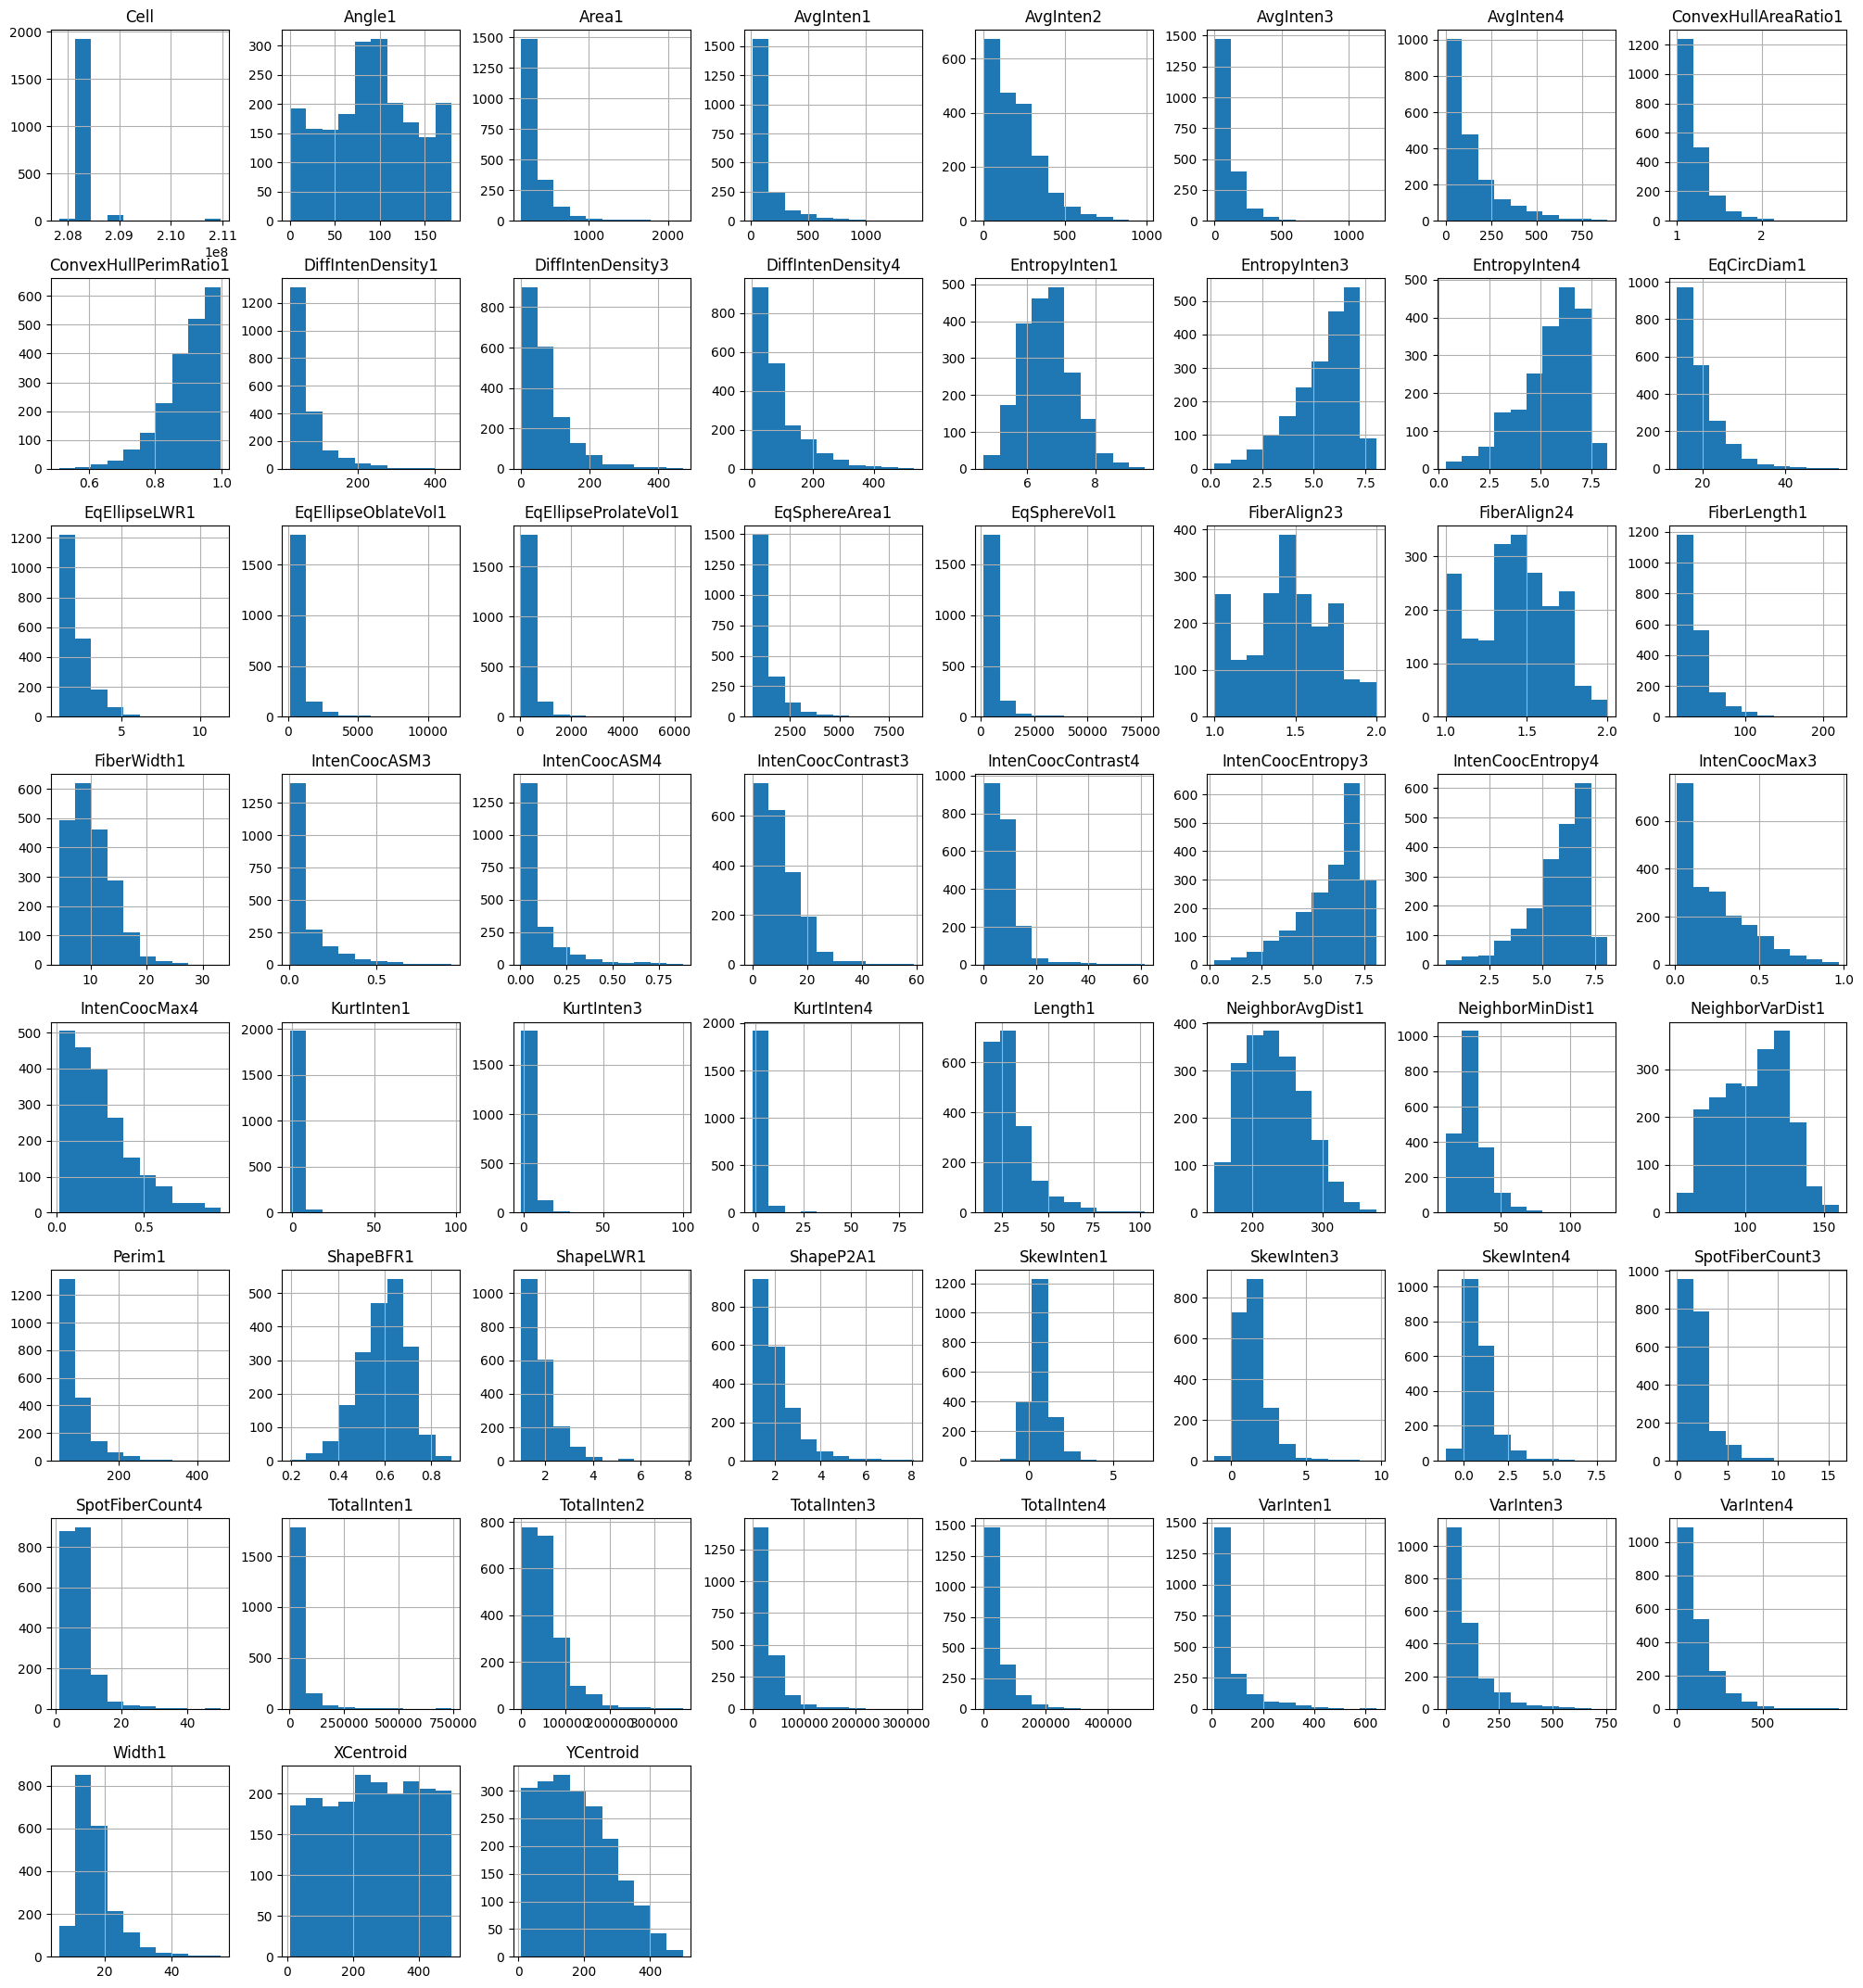

In [5]:
df.hist(figsize=(25,27))
plt.show()

## Pre-Processing

In [6]:
df['Class'] = (df['Class'] == 'PS').astype(int)
df = df.drop(['Case','Cell'],axis=1)
df.head()

,Class,Angle1,Area1,AvgInten1,AvgInten2,AvgInten3,AvgInten4,ConvexHullAreaRatio1,ConvexHullPerimRatio1,DiffIntenDensity1,...,TotalInten1,TotalInten2,TotalInten3,TotalInten4,VarInten1,VarInten3,VarInten4,Width1,XCentroid,YCentroid
0,1,143.247705,185,15.711864,4.954802,9.548023,2.214689,1.124509,0.919683,29.519231,...,2781,701,1690,392,12.474676,7.609035,2.714100,10.642974,42,14
1,1,133.752037,819,31.923274,206.878517,69.916880,164.153453,1.263158,0.797080,31.875000,...,24964,160998,54675,128368,18.809225,56.715352,118.388139,32.161261,215,347
2,0,106.646387,431,28.038835,116.315534,63.941748,106.696602,1.053310,0.935475,32.487710,...,11552,47511,26344,43959,17.295643,37.671053,49.470524,21.185525,371,252
3,1,69.150325,298,19.456140,102.294737,28.217544,31.028070,1.202625,0.865829,26.732283,...,5545,28870,8042,8843,13.818968,30.005643,24.749537,13.392830,487,295
4,1,2.887837,285,24.275735,112.415441,20.474265,40.577206,1.109333,0.956812,31.580645,...,6603,30306,5569,11037,15.407972,20.504288,45.450457,13.198561,283,159


### Feature engineering

In [7]:
df = pd.read_csv('segmentationData.csv')
df.columns = df.columns.str.replace("Ch", "")

# 1. Relative Biomarker Expression (Ratio)
df['Ratio_Marker3_to_Marker4'] = df['AvgInten3'] / (df['AvgInten4'] + 1e-6)

# 2. Biomarker Concentration (Density within Ch1 footprint)
df['Biomarker3_Density'] = df['TotalInten3'] / (df['Area1'] + 1e-6)

# 3. Biomarker 3 Heterogeneity Index
df['Biomarker3_Heterogeneity'] = df['IntenCoocEntropy3'] * df['VarInten3']

# 4. Spot/Fiber Concentration
df['Fiber_Density_Ch3'] = df['SpotFiberCount3'] / (df['Area1'] + 1e-6)

# 5. Distance from Cluster/Tissue Center
# Using the mean of X/Y centroids to find the center of your analyzed tissue/image
center_x = df['XCentroid'].mean()
center_y = df['YCentroid'].mean()
df['Distance_From_Center'] = np.sqrt((df['XCentroid'] - center_x)**2 + (df['YCentroid'] - center_y)**2)
df.head()

,Cell,Case,Class,Angle1,Area1,AvgInten1,AvgInten2,AvgInten3,AvgInten4,ConvexHullAreaRatio1,...,VarInten3,VarInten4,Width1,XCentroid,YCentroid,Ratio_Marker3_to_Marker4,Biomarker3_Density,Biomarker3_Heterogeneity,Fiber_Density_Ch3,Distance_From_Center
0,207827637,Test,PS,143.247705,185,15.711864,4.954802,9.548023,2.214689,1.124509,...,7.609035,2.714100,10.642974,42,14,4.311223,9.135135,54.780923,0.005405,272.988195
1,207932307,Train,PS,133.752037,819,31.923274,206.878517,69.916880,164.153453,1.263158,...,56.715352,118.388139,32.161261,215,347,0.425924,66.758242,386.919937,0.004884,175.711080
2,207932463,Train,WS,106.646387,431,28.038835,116.315534,63.941748,106.696602,1.053310,...,37.671053,49.470524,21.185525,371,252,0.599286,61.122970,285.550360,0.004640,133.168112
3,207932470,Train,PS,69.150325,298,19.456140,102.294737,28.217544,31.028070,1.202625,...,30.005643,24.749537,13.392830,487,295,0.909420,26.986577,189.414855,0.013423,255.034394
4,207932455,Test,PS,2.887837,285,24.275735,112.415441,20.474265,40.577206,1.109333,...,20.504288,45.450457,13.198561,283,159,0.504576,19.540351,138.979961,0.003509,28.854061


### Dimension Reduction

In [8]:
y = df['Class'].copy()
y = y.apply(lambda z: 1 if z =="PS" else 0)

x = df.drop(['Class','Case'],axis=1).copy()
print(x.__len__())
print(y.__len__())

2019
2019


#### Removing features with low target correlation

Features removed (|corr| < 0.1):
['Angle1', 'Area1', 'AvgInten3', 'Biomarker3_Density', 'Biomarker3_Heterogeneity', 'Cell', 'DiffIntenDensity3', 'Distance_From_Center', 'EqCircDiam1', 'EqEllipseOblateVol1', 'EqEllipseProlateVol1', 'EqSphereArea1', 'EqSphereVol1', 'FiberAlign23', 'FiberAlign24', 'Fiber_Density_Ch3', 'IntenCoocContrast4', 'KurtInten3', 'NeighborAvgDist1', 'NeighborMinDist1', 'NeighborVarDist1', 'SpotFiberCount3', 'SpotFiberCount4', 'TotalInten3', 'VarInten3', 'Width1', 'XCentroid', 'YCentroid']
Count removed: 28

New X shape: (2019, 36)


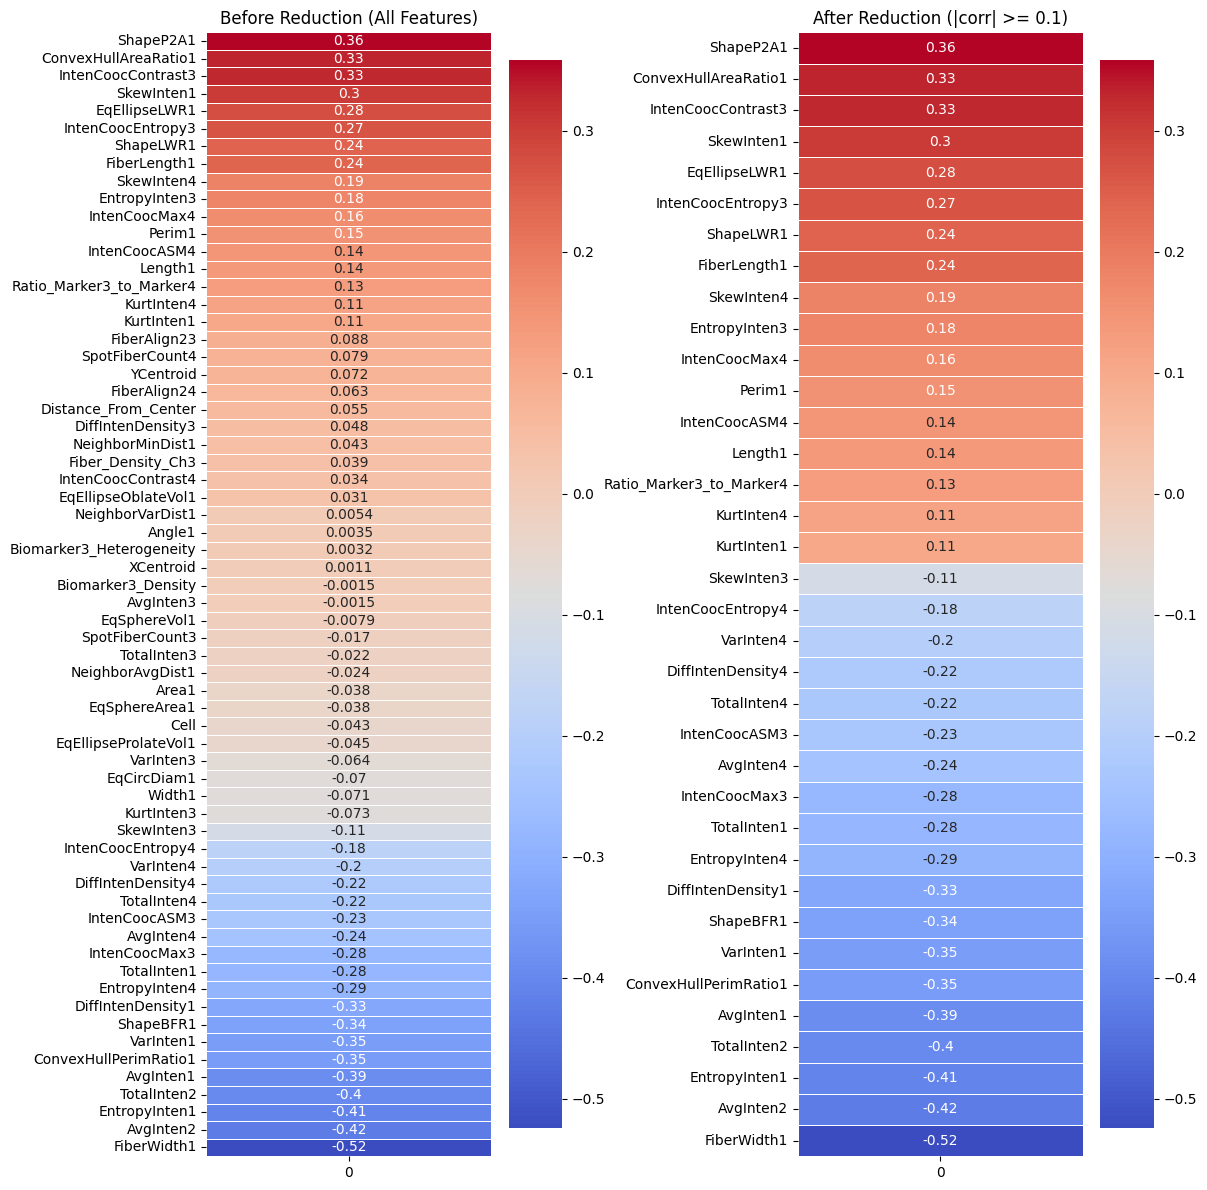

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# compute correlations
corr_all = x.corrwith(y).sort_values(ascending=False)

# filter out low-correlated features
threshold = 0.1
corr_filtered = corr_all[abs(corr_all) >= threshold]

# find removed features
removed_features = corr_all.index.difference(corr_filtered.index)

print(f"Features removed (|corr| < {threshold}):")
print(list(removed_features))
print(f"Count removed: {len(removed_features)}")

# --- REMOVE THEM FROM x ---
x_reduced_1 = x[corr_filtered.index]

print("\nNew X shape:", x_reduced_1.shape)

# plot both
plt.figure(figsize=(12, 12))

# BEFORE REDUCTION
plt.subplot(1, 2, 1)
sns.heatmap(
    corr_all.to_frame(),
    annot=True,
    cmap='coolwarm',
    linewidths=.5
)
plt.title("Before Reduction (All Features)")

# AFTER REDUCTION
plt.subplot(1, 2, 2)
sns.heatmap(
    corr_filtered.to_frame(),
    annot=True,
    cmap='coolwarm',
    linewidths=.5
)
plt.title(f"After Reduction (|corr| >= {threshold})")

plt.tight_layout()
plt.show()


#### Removing features with high correlation to each other


Removed due to HIGH inter-feature correlation (>0.85):
['ConvexHullAreaRatio1', 'ShapeLWR1', 'FiberLength1', 'EntropyInten3', 'Perim1', 'IntenCoocASM4', 'Length1', 'KurtInten4', 'IntenCoocEntropy4', 'DiffIntenDensity4', 'IntenCoocASM3', 'AvgInten4', 'IntenCoocMax3', 'EntropyInten4', 'VarInten1', 'AvgInten1']
Count: 16
Final shape: (2019, 20)


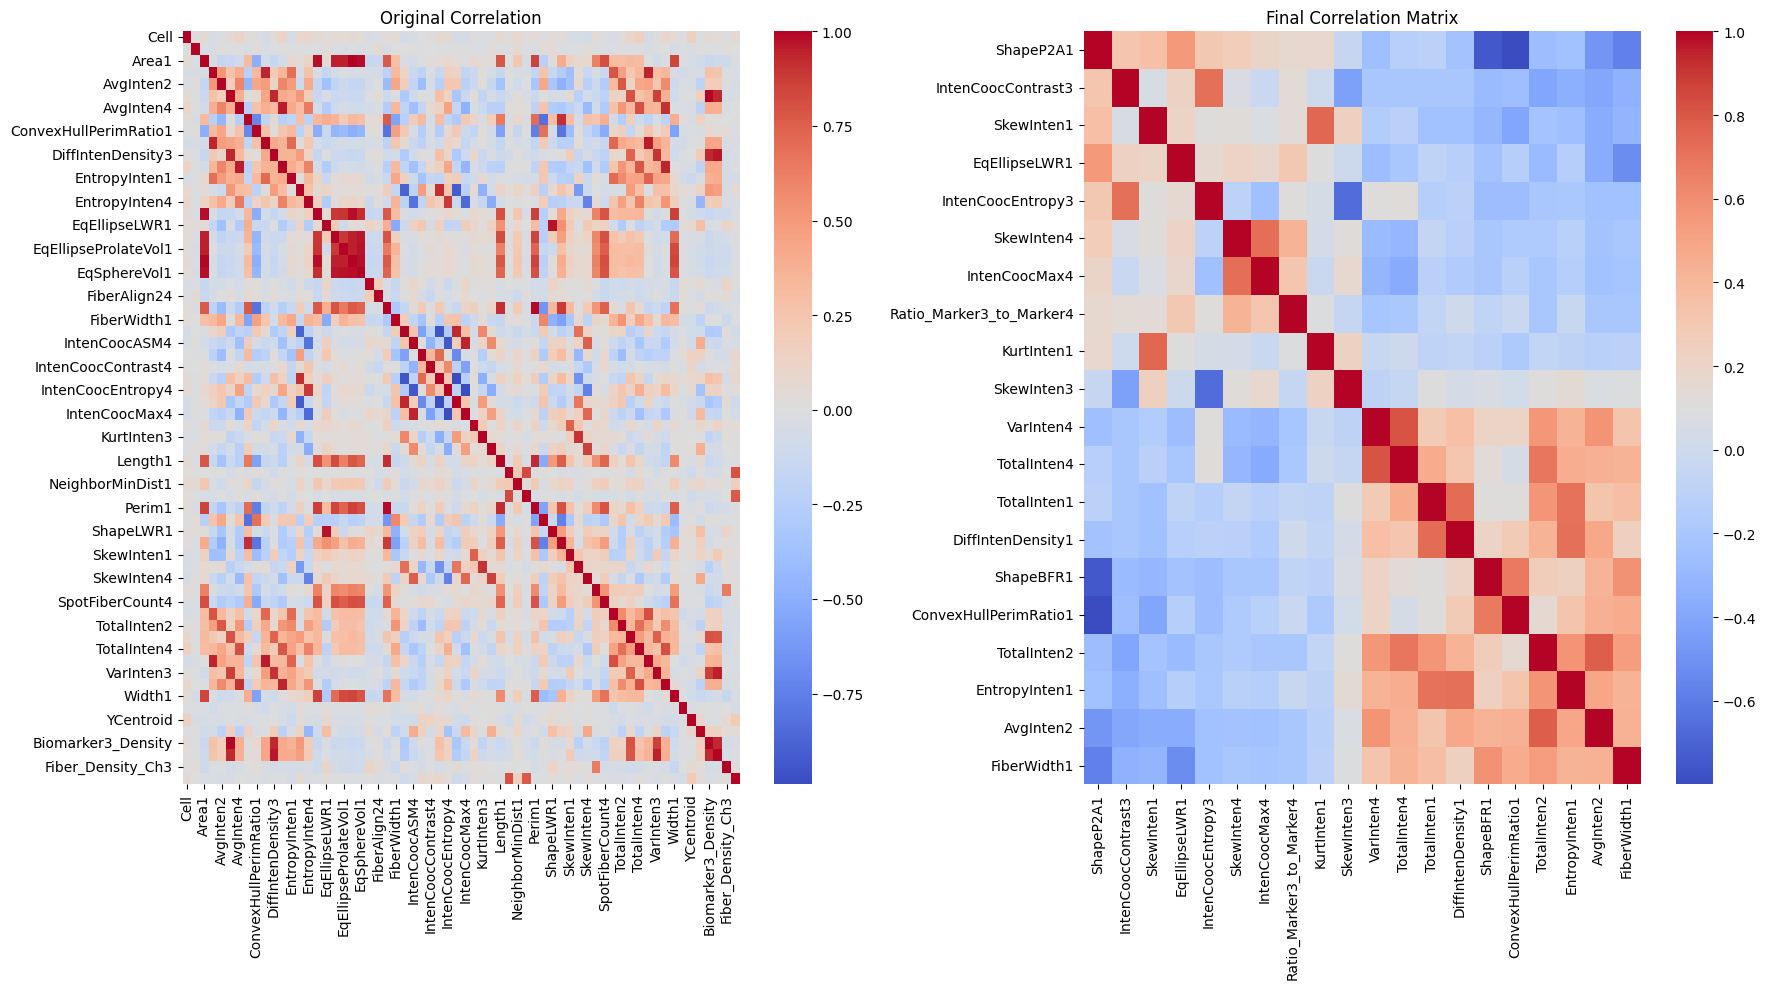

In [10]:
corr_matrix = x_reduced_1.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

threshold_high = 0.85

to_drop = [
    col for col in upper.columns 
    if any(upper[col] > threshold_high)
]

print(f"\nRemoved due to HIGH inter-feature correlation (>{threshold_high}):")
print(to_drop)
print("Count:", len(to_drop))

# reduce again
x_reduced_2 = x_reduced_1.drop(columns=to_drop)

print("Final shape:", x_reduced_2.shape)
# -----------------------------
# 3. PLOTS
# -----------------------------
plt.figure(figsize=(18,10))

# Before (all features)
plt.subplot(1,2,1)
sns.heatmap(x.corr(), cmap='coolwarm')
plt.title("Original Correlation")
# After high inter-correlation removal
plt.subplot(1,2,2)
sns.heatmap(x_reduced_2.corr(), cmap='coolwarm')
plt.title("Final Correlation Matrix")

plt.tight_layout()
plt.show()


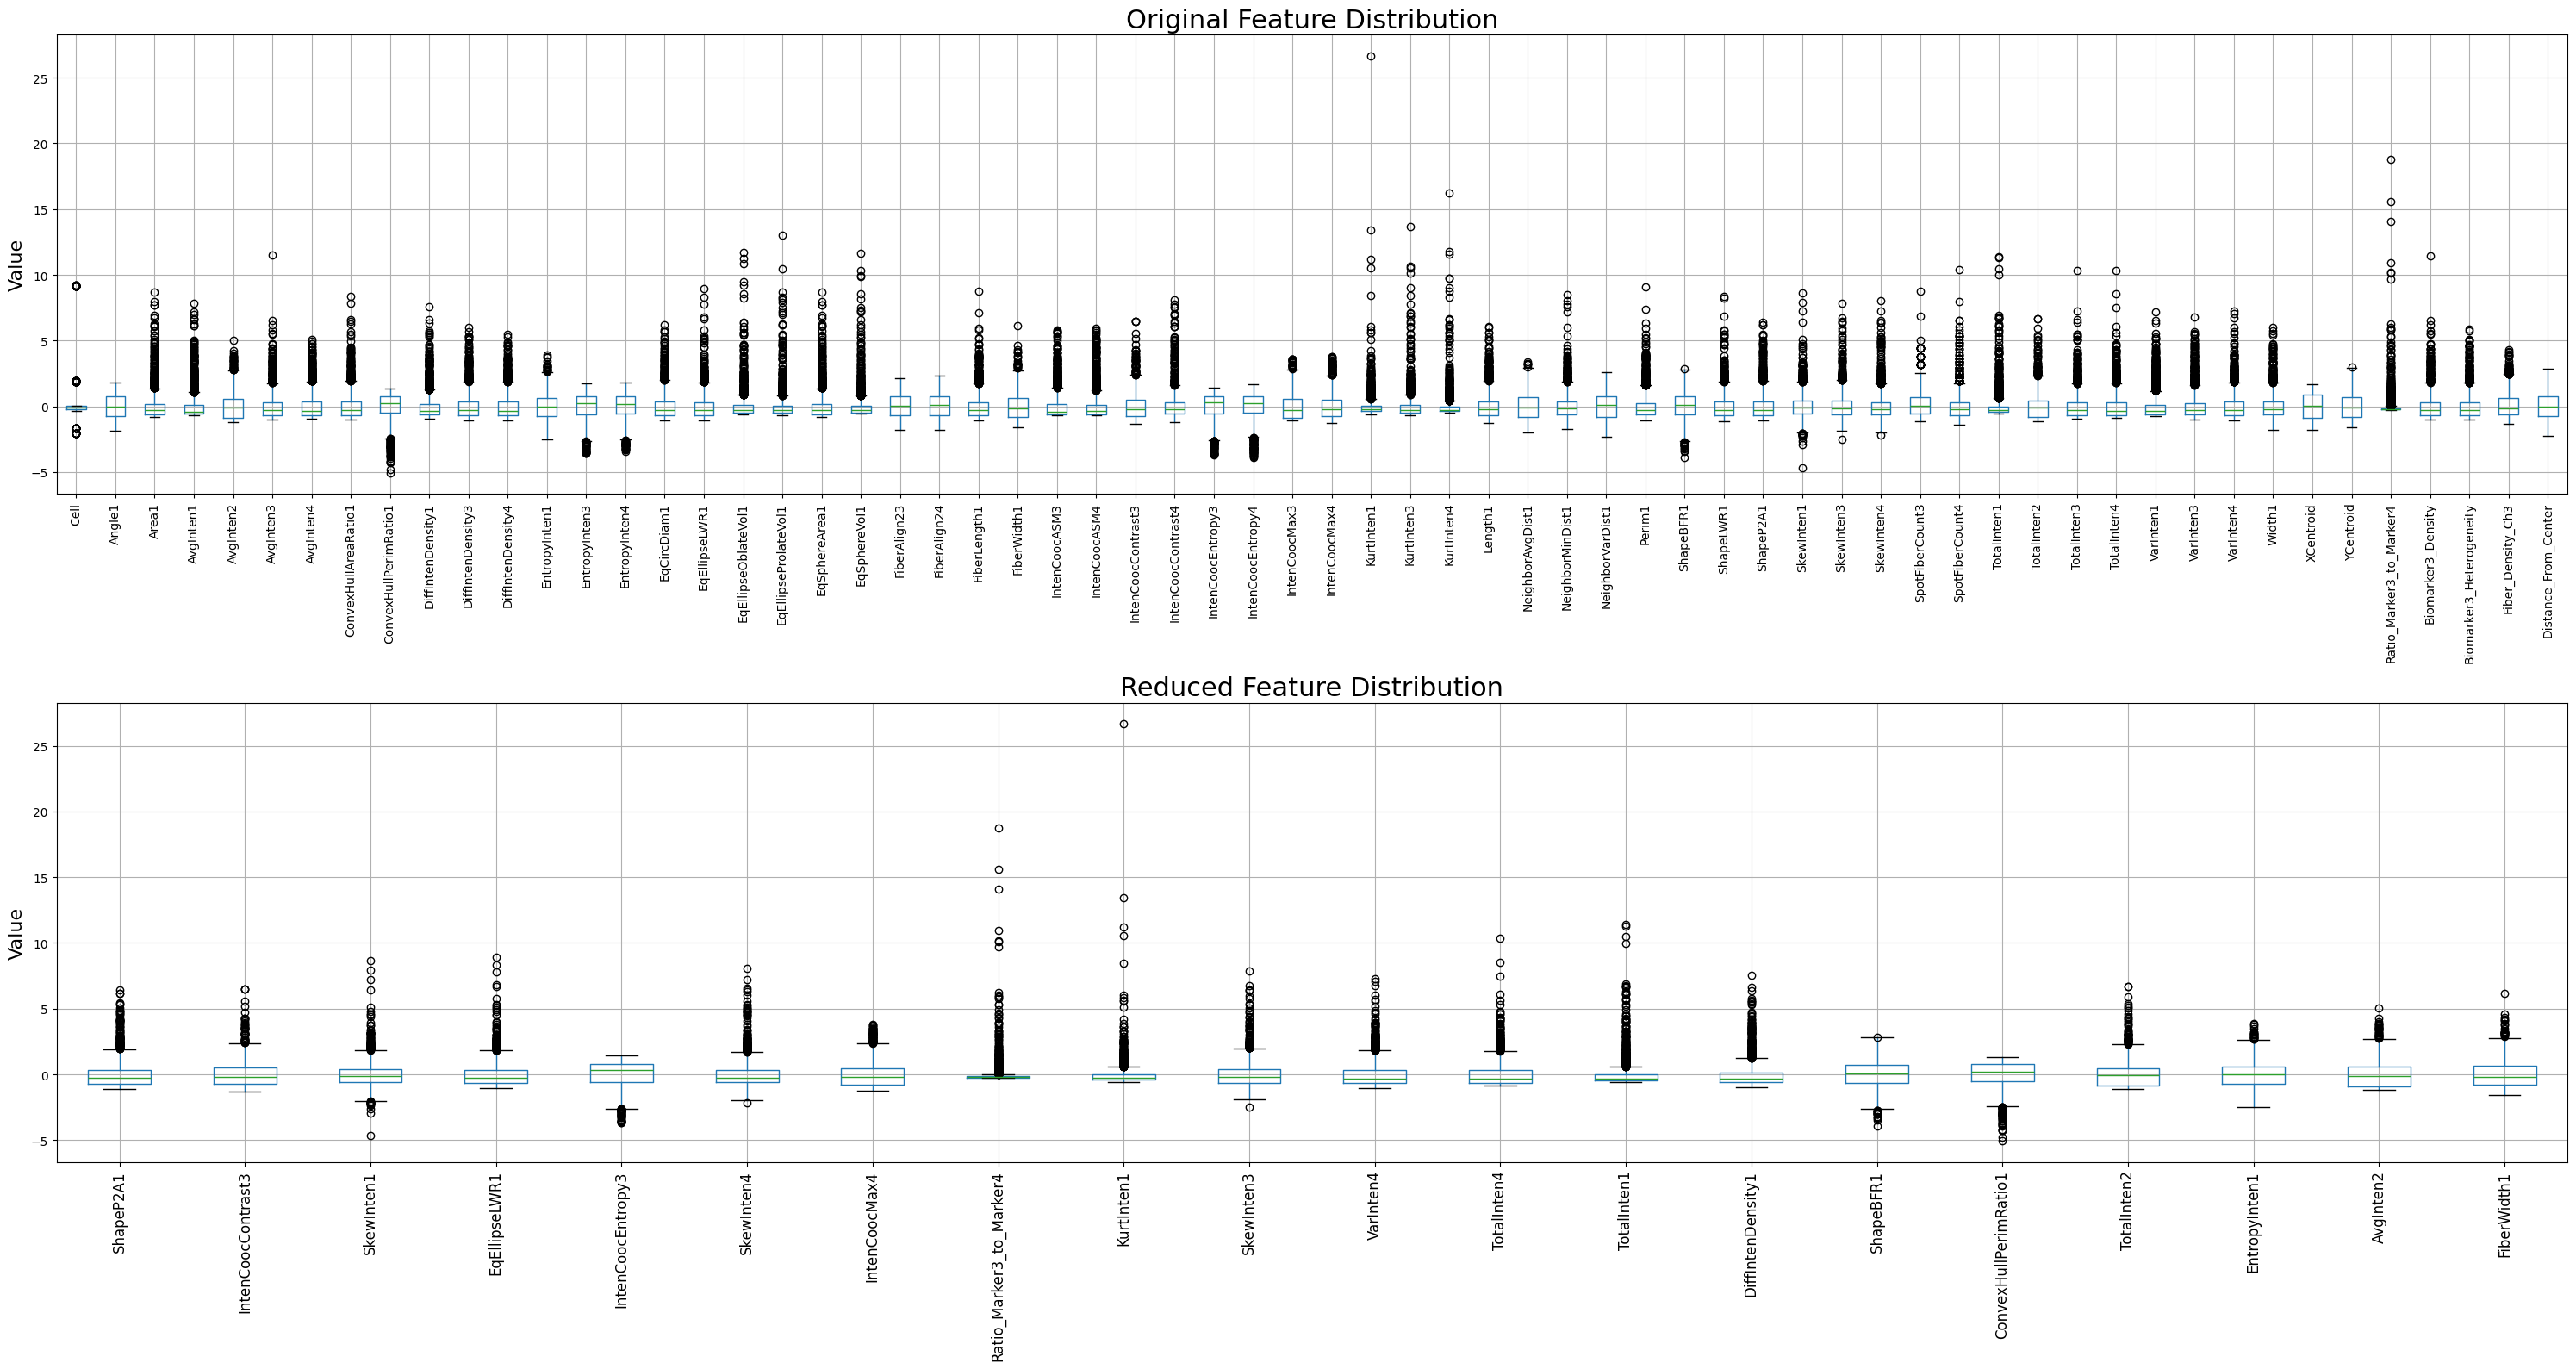

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(30,16))

plt.subplot(2,1,1)

pd.DataFrame(StandardScaler().fit_transform(x),columns=x.columns).boxplot()
plt.title("Original Feature Distribution", fontsize=22)
plt.xticks(rotation=90, fontsize=10)
plt.ylabel("Value", fontsize=16)

plt.subplot(2,1,2)
pd.DataFrame(StandardScaler().fit_transform(x_reduced_2),columns=x_reduced_2.columns).boxplot()

plt.title("Reduced Feature Distribution", fontsize=22)
plt.xticks(rotation=90, fontsize=12)
plt.ylabel("Value", fontsize=16)

plt.tight_layout()
plt.show()


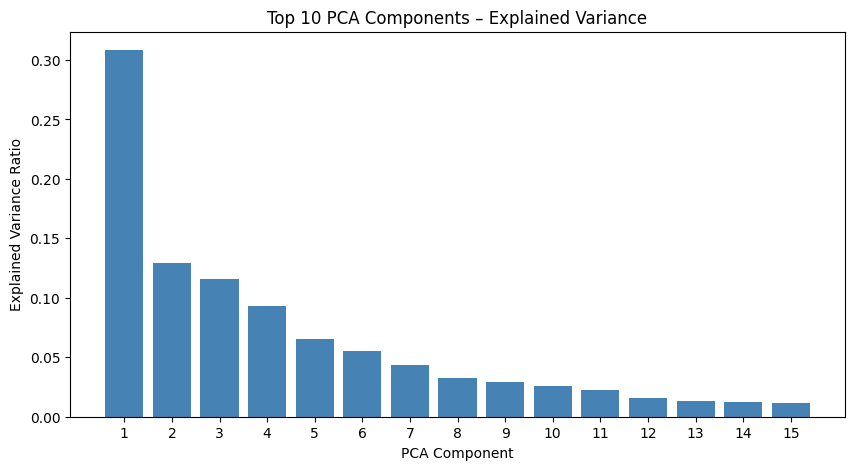

In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

scaler = StandardScaler()
scaled = scaler.fit_transform(x_reduced_2)

pca_full = PCA(n_components=15)
pca_full.fit(scaled)

# Bar plot for top 10 components
plt.figure(figsize=(10,5))
plt.bar(range(1, 16), pca_full.explained_variance_ratio_, color='steelblue')
plt.xticks(range(1, 16))
plt.xlabel("PCA Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Top 10 PCA Components – Explained Variance")
plt.show()

#### spliting train and test

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler


X_train,X_test,y_train,y_test = train_test_split(x_reduced_2,y,random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### outlier removal

In [14]:
for col in X_train.columns:
    mean = X_train[col].mean()
    std = X_train[col].std()
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    iqr_outliers = ((X_train[col] < Q1 - 1.5*IQR) | (X_train[col] > Q3 + 1.5*IQR)).sum()
    iqr_outliers_percentage = (iqr_outliers / len(X_train)) * 100

    outlier_count = (abs(X_train[col] - mean) > 3 * std).sum()
    percentage = (outlier_count / len(X_train)) * 100
    print(f"{col}:   Mean: {mean},   Std: {std},   Outliers: {round(percentage,2)},  Outliers: {round(iqr_outliers_percentage,2)},")


ShapeP2A1:   Mean: 2.0417508052747304,   Std: 0.9430385285957211,   Outliers: 1.78,  Outliers: 4.76,
IntenCoocContrast3:   Mean: 9.995359974593288,   Std: 7.648504115297158,   Outliers: 1.52,  Outliers: 2.25,
SkewInten1:   Mean: 0.6941393725882322,   Std: 0.7417205827954331,   Outliers: 1.19,  Outliers: 5.35,
EqEllipseLWR1:   Mean: 2.1113603610863065,   Std: 1.0622253126123882,   Outliers: 1.25,  Outliers: 5.48,
IntenCoocEntropy3:   Mean: 5.899792557450304,   Std: 1.535396135791696,   Outliers: 1.25,  Outliers: 2.64,
SkewInten4:   Mean: 0.9105735179903997,   Std: 0.8384170602632065,   Outliers: 1.39,  Outliers: 5.48,
IntenCoocMax4:   Mean: 0.24267227287147233,   Std: 0.17990574836475165,   Outliers: 1.32,  Outliers: 2.91,
Ratio_Marker3_to_Marker4:   Mean: 2.8619921303376943,   Std: 10.019596790399799,   Outliers: 1.65,  Outliers: 13.67,
KurtInten1:   Mean: 0.9058978730859606,   Std: 3.9899626156308785,   Outliers: 0.86,  Outliers: 10.83,
SkewInten3:   Mean: 1.491528160991487,   Std: 1.

In [15]:
from sklearn.ensemble import IsolationForest

# fit on train data
iso = IsolationForest(contamination=0.05, random_state=42)
pred = iso.fit_predict(X_train)

# -1 = outlier , 1 = normal
iso_outliers = (pred == -1).sum()
iso_percentage = (iso_outliers / len(X_train)) * 100

print(f"\nIsolationForest -> Outliers: {iso_outliers} ({round(iso_percentage,2)}%)\n")


IsolationForest -> Outliers: 76 (5.02%)



In [16]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05)
outliers = iso.fit_predict(X_train)
print(outliers)

[1 1 1 ... 1 1 1]


## Visualization 

c:\Users\iCFixer.ir\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


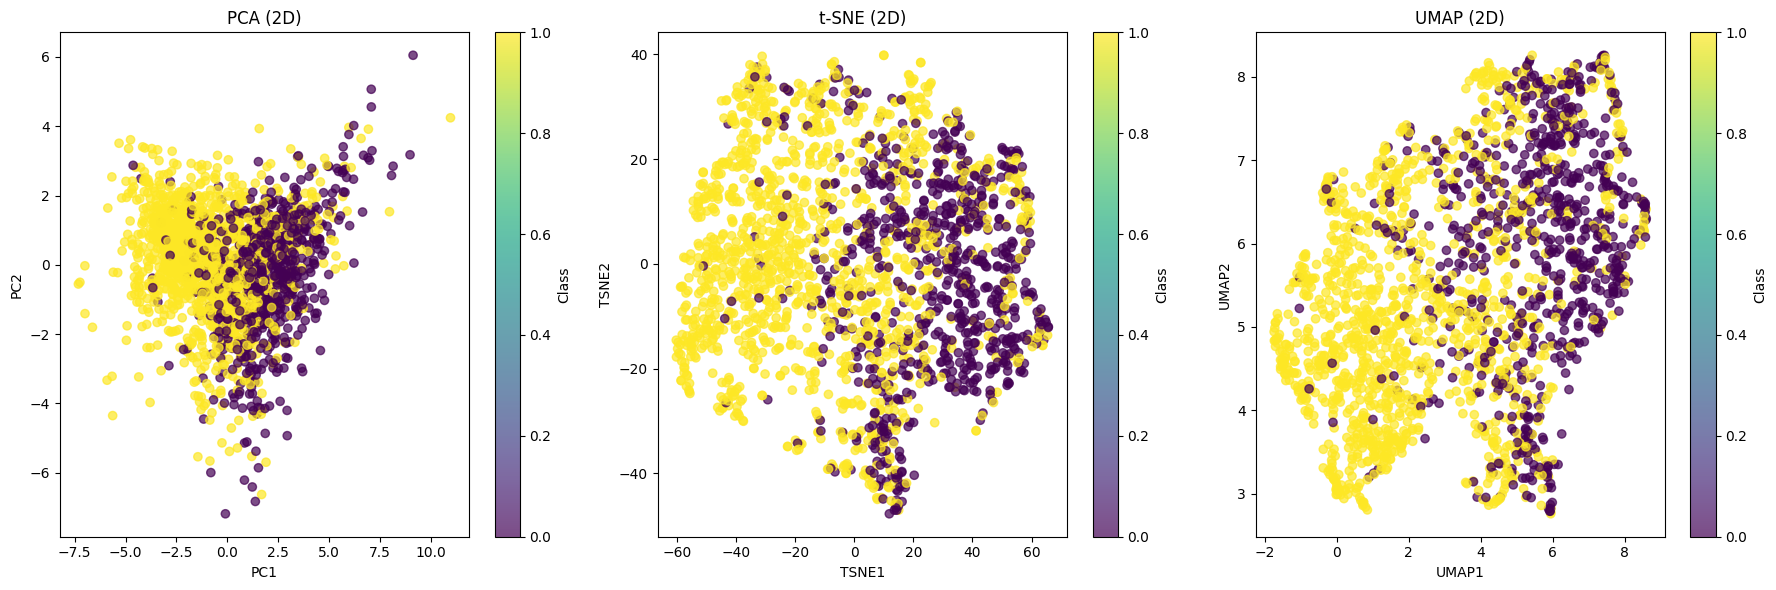

In [39]:
#----------------------------------------------------
# Standardize
#----------------------------------------------------
scaler = StandardScaler()
scaled = scaler.fit_transform(x_reduced_2)


#----------------------------------------------------
# PCA 2D
#----------------------------------------------------
pca2 = PCA(n_components=2)
pca_2d = pca2.fit_transform(scaled)

pca_df = pd.DataFrame(pca_2d, columns=['PC1', 'PC2'])

#----------------------------------------------------
# t-SNE 2D
#----------------------------------------------------
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=1000)
tsne_2d = tsne.fit_transform(scaled)

tsne_df = pd.DataFrame(tsne_2d, columns=['TSNE1', 'TSNE2'])

#----------------------------------------------------
# UMAP 2D
#----------------------------------------------------
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=32,
    min_dist=0.1,
    metric='euclidean'
)
umap_2d = umap_model.fit_transform(scaled)

umap_df = pd.DataFrame(umap_2d, columns=['UMAP1', 'UMAP2'])

#----------------------------------------------------
# Side‑by‑side comparison: PCA vs t-SNE vs UMAP
#----------------------------------------------------
plt.figure(figsize=(18,6))

# PCA
plt.subplot(1,3,1)
s1 = plt.scatter(
    pca_df['PC1'], pca_df['PC2'],
    c=y, cmap='viridis', alpha=0.7
)
plt.title("PCA (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(s1, label="Class")

# t-SNE
plt.subplot(1,3,2)
s2 = plt.scatter(
    tsne_df['TSNE1'], tsne_df['TSNE2'],
    c=y, cmap='viridis', alpha=0.7
)
plt.title("t-SNE (2D)")
plt.xlabel("TSNE1")
plt.ylabel("TSNE2")
plt.colorbar(s2, label="Class")

# UMAP
plt.subplot(1,3,3)
s3 = plt.scatter(
    umap_df['UMAP1'], umap_df['UMAP2'],
    c=y, cmap='viridis', alpha=0.7
)
plt.title("UMAP (2D)")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.colorbar(s3, label="Class")

plt.tight_layout()
plt.show()


In [42]:
import plotly.graph_objects as go
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import pandas as pd

#---------------------------------------
# Standardize data
#---------------------------------------
scaler = StandardScaler()
scaled = scaler.fit_transform(x_reduced_2)

#---------------------------------------
# 3D PCA
#---------------------------------------
pca = PCA(n_components=3)
pca3 = pca.fit_transform(scaled)

pca_df = pd.DataFrame(pca3, columns=['PC1','PC2','PC3'])

#---------------------------------------
# 3D t-SNE
#---------------------------------------
tsne = TSNE(n_components=3, perplexity=30, learning_rate=200, n_iter=1000)
tsne3 = tsne.fit_transform(scaled)

tsne_df = pd.DataFrame(tsne3, columns=['TSNE1','TSNE2','TSNE3'])

#---------------------------------------
# Plotly figure with 2 subplots
#---------------------------------------
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'scene'}, {'type': 'scene'}]],
    subplot_titles=("3D PCA", "3D t-SNE")
)

# --- PCA ---
fig.add_trace(
    go.Scatter3d(
        x=pca_df['PC1'],
        y=pca_df['PC2'],
        z=pca_df['PC3'],
        mode='markers',
        marker=dict(
            size=3,
            color=y,      # colors by class
            colorscale='Viridis',
            opacity=0.85
        )
    ),
    row=1, col=1
)

# --- t‑SNE ---
fig.add_trace(
    go.Scatter3d(
        x=tsne_df['TSNE1'],
        y=tsne_df['TSNE2'],
        z=tsne_df['TSNE3'],
        mode='markers',
        marker=dict(
            size=3,
            color=y,
            colorscale='Viridis',
            opacity=0.85
        )
    ),
    row=1, col=2
)

fig.update_layout(
    height=600,
    width=1000,
    showlegend=False,
    title="Interactive 3D PCA vs 3D t‑SNE"
)

fig.show()


c:\Users\iCFixer.ir\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


## Model Training

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, accuracy_score, recall_score
import math

def plot_all_confusions(models, model_names, X_test, y_test, cols=2,threshold=.5):
    rows = math.ceil(len(models) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*7, rows*6))
    axes = axes.flatten()

    for i, (model, name) in enumerate(zip(models, model_names)):
        predictions = model.predict(X_test)
        predictions = (predictions.ravel() >= threshold).astype(int)

        cm = confusion_matrix(y_test, predictions)
        precision = precision_score(y_test, predictions)
        accuracy = accuracy_score(y_test, predictions)
        sensitivity = recall_score(y_test, predictions)

        ax = axes[i]

        sns.heatmap(cm, annot=True, fmt='d',  ax=ax)

        ax.set_title(name)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

        metrics_text = (
            f"Accuracy: {accuracy:.4f}\n"
            f"Precision: {precision:.4f}\n"
            f"Sensitivity: {sensitivity:.4f}\n"
        )

        ax.text(
            0.5, -0.25,
            metrics_text,
            transform=ax.transAxes,
            ha="center",
            fontsize=11
        )

    plt.tight_layout()
    plt.show()

def plot_confusion_mat(ml_model, x_test1, y_test1, title="Confusion Matrix"):

    # probabilities from keras model
    y_prob = ml_model.predict(x_test1).ravel()

    # apply threshold
    y_pred = (y_prob >= 0.5).astype(int)

    # metrics
    cm = confusion_matrix(y_test1, y_pred)
    precision = precision_score(y_test1, y_pred)
    accuracy = accuracy_score(y_test1, y_pred)
    sensitivity = recall_score(y_test1, y_pred)

    # plot
    fig, ax = plt.subplots(figsize=(6,5))

    sns.heatmap(cm, annot=True, fmt='d', ax=ax)

    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    metrics_text = (
        f"Accuracy: {accuracy:.4f}\n"
        f"Precision: {precision:.4f}\n"
        f"Sensitivity: {sensitivity:.4f}"
    )

    ax.text(
        0.5, -0.25,
        metrics_text,
        transform=ax.transAxes,
        ha="center",
        fontsize=11
    )

    plt.show()

In [18]:
print(f"train len :{X_train_scaled.__len__()}")
print(f"train len :{X_test_scaled.__len__()}")

train len :1514
train len :505


#### Suport Vector Machine

In [19]:
from sklearn.svm import SVC
clf_svm = SVC(random_state = 42)
clf_svm.fit(X_train_scaled,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


#### Random Forest

In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 3, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_features': ['sqrt', 'log2', None]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=3,
    random_state=42
)

random_search.fit(X_train, y_train)

clf_RandomForest = random_search.best_estimator_

print(random_search.best_params_)
print(random_search.best_score_)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 20, 'criterion': 'gini'}
0.8697671738950594


#### KNN

In [82]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np
import plotly.graph_objects as go

ks = range(2, 25)
f1_scores = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(
        knn,
        X_train_scaled,
        y_train,
        cv=cv,
        scoring="f1"
    )

    f1_scores.append(scores.mean())

# Best k
best_k = ks[np.argmax(f1_scores)]
print("Best k:", best_k)
print("Best CV F1:", max(f1_scores))

# Interactive plot
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=list(ks),
        y=f1_scores,
        mode='lines+markers',
        name='CV F1 Score'
    )
)

fig.update_layout(
    title='KNN Cross‑Validated F1 vs k',
    xaxis_title='k value',
    yaxis_title='Mean F1 Score',
    hovermode='x unified'
)

fig.show()


Best k: 15
Best CV F1: 0.8566536732732709


In [83]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",15
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


#### Neural Network

In [31]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from scikeras.wrappers import KerasClassifier

# 2. Define the model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')      # binary classification
])

# 3. Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 4. Train
history = model.fit(
    X_train_scaled, y_train,
    epochs=40,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)
nn_model = KerasClassifier(
    model=model,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)


In [41]:
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping


def build_model(hp):

    model = keras.Sequential()

    # First hidden layer
    model.add(layers.Dense(
        units=hp.Int("units1", min_value=16, max_value=128, step=16),
        activation="relu",
        input_shape=(X_train.shape[1],)
    ))

    model.add(layers.Dropout(
        hp.Float("dropout1", 0.0, 0.5, step=0.1)
    ))

    # Second hidden layer
    model.add(layers.Dense(
        units=hp.Int("units2", min_value=8, max_value=64, step=8),
        activation="relu"
    ))

    model.add(layers.Dropout(
        hp.Float("dropout2", 0.0, 0.5, step=0.1)
    ))

    model.add(layers.Dense(
        units=hp.Int("units2", min_value=8, max_value=64, step=8),
        activation="relu"
    ))

    model.add(layers.Dropout(
        hp.Float("dropout2", 0.0, 0.5, step=0.1)
    ))
    # Output layer
    model.add(layers.Dense(1, activation="sigmoid"))

    # Optimizer tuning
    learning_rate = hp.Choice(
        "learning_rate",
        values=[1e-2, 1e-3, 1e-4]
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [42]:
tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=10,
    executions_per_trial=1,
    directory="keras_tuner_results",
    project_name="nn_tuning"
)

# show search space
tuner.search_space_summary()


early_stop = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)


tuner.search(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

c:\Users\iCFixer.ir\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Search space summary
Default search space size: 5
units1 (Int)
{'default': None, 'conditions': [], 'min_value': 16, 'max_value': 128, 'step': 16, 'sampling': 'linear'}
dropout1 (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
units2 (Int)
{'default': None, 'conditions': [], 'min_value': 8, 'max_value': 64, 'step': 8, 'sampling': 'linear'}
dropout2 (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}


In [43]:
import pandas as pd

trials = tuner.oracle.trials
data = []

for trial_id, trial in trials.items():
    row = trial.hyperparameters.values.copy()
    row["trial_id"] = trial_id
    row["score"] = trial.score
    data.append(row)

pd.DataFrame(data).sort_values("score", ascending=False)

,units1,dropout1,units2,dropout2,learning_rate,trial_id,score
7,32,0.1,56,0.0,0.0010,07,0.823529
6,128,0.3,40,0.2,0.0001,06,0.811145
2,96,0.2,64,0.0,0.0100,02,0.801858
0,112,0.2,40,0.3,0.0001,00,0.801858
8,48,0.2,16,0.4,0.0100,08,0.795666
3,48,0.3,8,0.0,0.0010,03,0.792570
9,32,0.1,16,0.1,0.0001,09,0.789474
1,64,0.3,64,0.0,0.0001,01,0.786378
5,80,0.3,48,0.0,0.0001,05,0.786378
4,112,0.4,16,0.2,0.0001,04,0.780186


c:\Users\iCFixer.ir\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


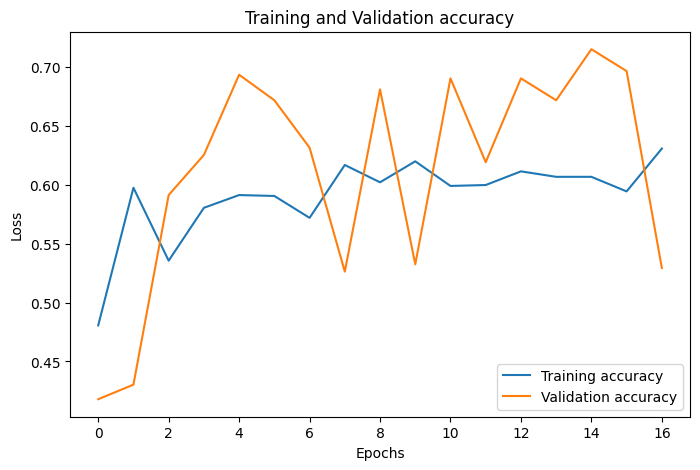

In [45]:
from scikeras.wrappers import KerasClassifier

best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

best_model = tuner.hypermodel.build(best_hp)

nn_model = KerasClassifier(
    model=best_model,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)
history = best_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation accuracy')
plt.legend()
plt.show()


In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

def plot_multi_roc(models, model_names, X_test, y_test):

    plt.figure(figsize=(7,6))

    for model, name in zip(models, model_names):

        # get probabilities depending on model type
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:,1]
        else:  # keras model
            y_prob = model.predict(X_test).ravel()

        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc_score = roc_auc_score(y_test, y_prob)

        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

    # random classifier
    plt.plot([0,1], [0,1], linestyle="--", color="gray")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves Comparison")
    plt.legend()
    plt.grid(True)

    plt.show()

def plot_threshold_metrics(model, X_test, y_test, model_name="Model"):

    y_prob = model.predict(X_test).ravel()

    # Step 2 – thresholds to evaluate
    thresholds = np.linspace(0, 1, 101)

    accuracies = []
    precisions = []
    recalls = []
    specificities = []
    f1s = []

    # Step 3 – evaluate each threshold
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)

        # confusion matrix for specificity
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

        accuracies.append(accuracy_score(y_test, y_pred))
        precisions.append(precision_score(y_test, y_pred, zero_division=0))
        recalls.append(recall_score(y_test, y_pred))
        specificities.append(tn / (tn + fp))
        f1s.append(f1_score(y_test, y_pred))

    # Step 4 – plot
    plt.figure(figsize=(10, 6))

    plt.plot(thresholds, accuracies, label="Accuracy", linewidth=2)
    plt.plot(thresholds, precisions, label="Precision", linewidth=2)
    plt.plot(thresholds, recalls, label="Recall (Sensitivity)", linewidth=2)
    plt.plot(thresholds, specificities, label="Specificity", linewidth=2)
    plt.plot(thresholds, f1s, label="F1 Score", linewidth=2)

    plt.xlabel("Threshold")
    plt.ylabel("Metric Value")
    plt.title(f"Threshold vs Metrics – {model_name}")
    plt.legend(loc="best")
    plt.grid(True)
    plt.ylim(0, 1)

    plt.show()


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


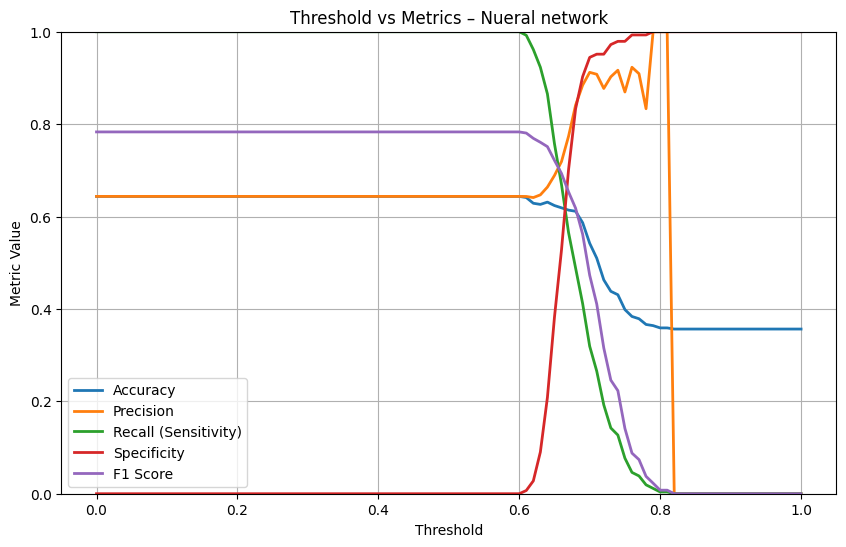

In [47]:
plot_threshold_metrics(best_model, X_test_scaled, y_test, model_name="Nueral network")

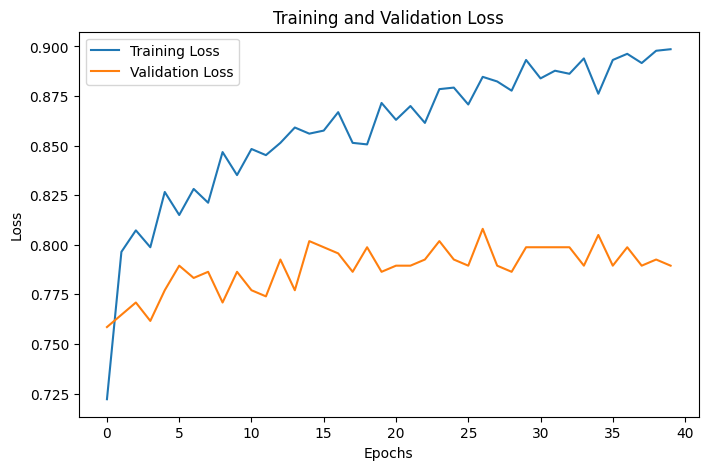

In [25]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Loss')
plt.plot(history.history['val_accuracy'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


## Evaluation & Results

c:\Users\iCFixer.ir\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


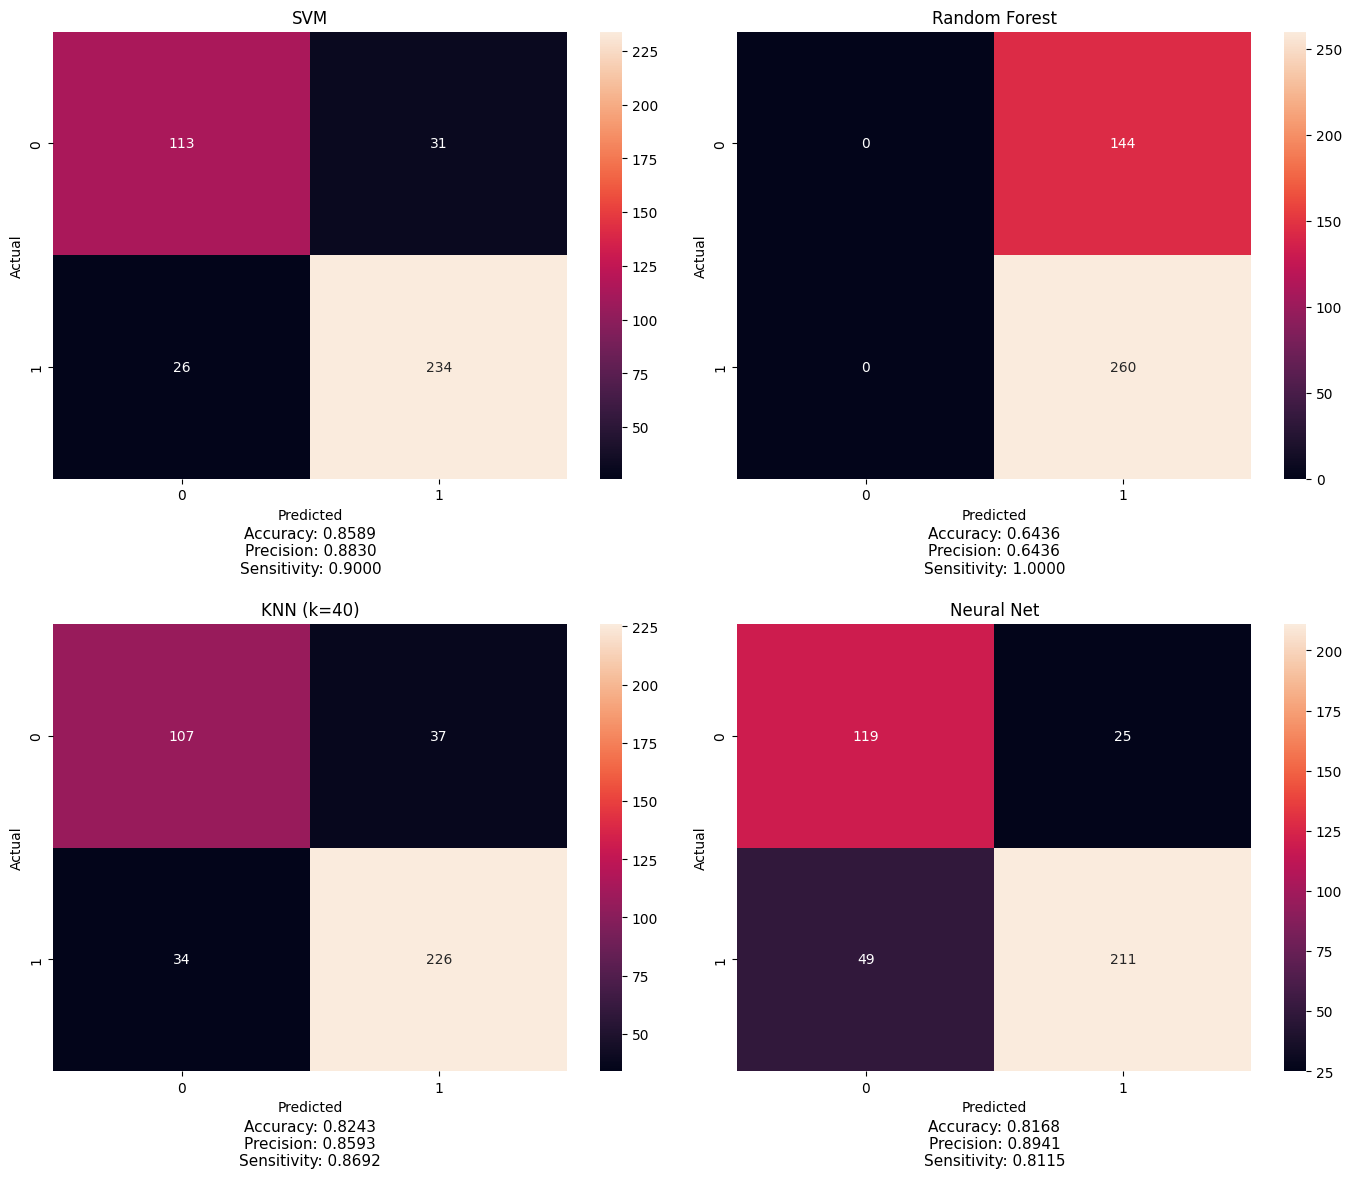

In [78]:
models = [
    clf_svm,
    clf_RandomForest,
    knn,
    model
]

model_names = [
    "SVM",
    "Random Forest",
    "KNN (k=40)",
    "Neural Net"
]

plot_all_confusions(models, model_names, X_test_scaled, y_test,threshold=0.7)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


c:\Users\iCFixer.ir\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


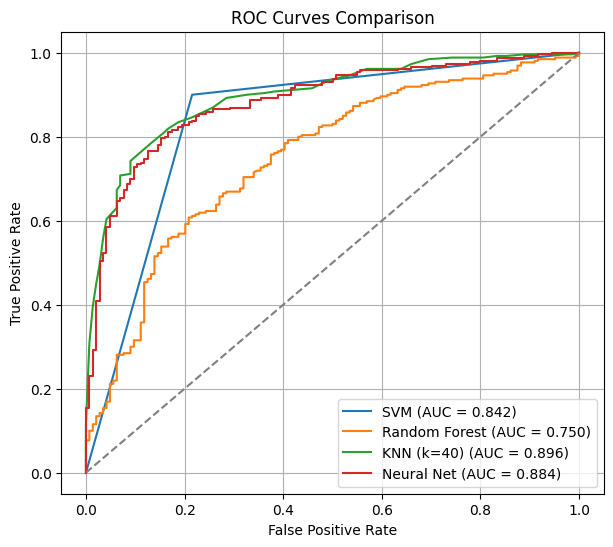

In [84]:
plot_multi_roc(models, model_names, X_test_scaled, y_test)

In [85]:
import pandas as pd
from sklearn.model_selection import cross_validate, StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1' ]

results = {}

def evaluate_model_cv(model, X, y, name):
    cv_results = cross_validate(model, X, y, cv=skf, scoring=scoring)
    results[name] = {metric: cv_results[f'test_{metric}'].mean() for metric in scoring}

evaluate_model_cv(clf_svm, X_train_scaled, y_train, "Best SVM")
evaluate_model_cv(nn_model, X_train_scaled, y_train, "Neural Network")
evaluate_model_cv(clf_RandomForest, X_train_scaled, y_train, "Random Forest")
evaluate_model_cv(knn, X_train_scaled, y_train, "KNN")

c:\Users\iCFixer.ir\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
c:\Users\iCFixer.ir\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
c:\Users\iCFixer.ir\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
c:\Users\iCFixer.ir\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping con

In [86]:
summary = pd.DataFrame(results).T.round(4).sort_values(by='f1',ascending=False)
display(summary.style.background_gradient(cmap="YlGnBu"))

,accuracy,precision,recall,f1
Neural Network,0.839000,0.880900,0.867300,0.873900
Random Forest,0.833400,0.864200,0.880800,0.872000
Best SVM,0.819200,0.855600,0.865400,0.860300
KNN,0.817300,0.865800,0.848100,0.856700
